# 02 — Data Cleaning & Validation
Validate every step of the ETL pipeline. Documents what was removed and why.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.etl.pipeline import load_raw, clean, build_product_features, build_monthly_features
from pathlib import Path
PROCESSED = Path('../data/processed')
print('Imports OK')

Imports OK


## 1. Raw data audit

In [2]:
df_raw = load_raw()
print(f'Raw shape: {df_raw.shape}')
print(f'\nColumn dtypes:')
print(df_raw.dtypes)
print(f'\nMissing values:')
print(df_raw.isnull().sum())

2026-03-27 05:34:54,195 - INFO - Loading raw data from /mnt/d/DS_PROJECTS/Retailers_AI_ Pricing/data/raw/Online Retail.xlsx
2026-03-27 05:36:19,072 - INFO - Loaded 541,909 rows, 8 columns


Raw shape: (541909, 8)

Column dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 2. Step-by-step cleaning audit

In [3]:
df = df_raw.copy()
steps = []

steps.append(('Raw', len(df)))

df = df.dropna(subset=['CustomerID', 'Description'])
steps.append(('Drop missing CustomerID/Description', len(df)))

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
steps.append(('Remove cancellations (InvoiceNo starts with C)', len(df)))

df = df[df['Quantity'] > 0]
steps.append(('Remove Quantity <= 0', len(df)))

df = df[df['UnitPrice'] > 0]
steps.append(('Remove UnitPrice <= 0', len(df)))

price_cap = df.groupby('StockCode')['UnitPrice'].transform(lambda x: x.quantile(0.99))
df = df[df['UnitPrice'] <= price_cap]
steps.append(('Remove price outliers (>99th pct per product)', len(df)))

audit = pd.DataFrame(steps, columns=['Step', 'Rows remaining'])
audit['Rows removed'] = audit['Rows remaining'].shift(1).fillna(audit['Rows remaining'].iloc[0]).astype(int) - audit['Rows remaining']
audit['% removed'] = (audit['Rows removed'] / audit['Rows remaining'].iloc[0] * 100).round(2)
print(audit.to_string(index=False))

                                          Step  Rows remaining  Rows removed  % removed
                                           Raw          541909             0       0.00
           Drop missing CustomerID/Description          406829        135080      24.93
Remove cancellations (InvoiceNo starts with C)          397924          8905       1.64
                          Remove Quantity <= 0          397924             0       0.00
                         Remove UnitPrice <= 0          397884            40       0.01
 Remove price outliers (>99th pct per product)          396777          1107       0.20


## 3. Anomaly check — price outliers

In [4]:
# Products with suspiciously high prices in raw data
suspicious = df_raw[df_raw['UnitPrice'] > 100].groupby(['StockCode', 'Description'])['UnitPrice'].agg(['min','max','count']).reset_index()
suspicious.columns = ['StockCode', 'Description', 'min_price', 'max_price', 'occurrences']
print(f'Products with UnitPrice > £100 in raw data:')
print(suspicious.sort_values('max_price', ascending=False).head(10).to_string(index=False))

Products with UnitPrice > £100 in raw data:
   StockCode                    Description  min_price  max_price  occurrences
           M                         Manual     102.64   38970.00          203
   AMAZONFEE                     AMAZON FEE     219.76   17836.46           33
           B                Adjust bad debt   11062.06   11062.06            1
        POST                        POSTAGE     134.00    8142.75           18
         DOT                 DOTCOM POSTAGE     100.17    4505.17          604
           D                       Discount     102.24    1867.86           11
        CRUK                CRUK Commission     361.59    1100.44           12
BANK CHARGES                   Bank Charges     109.84    1050.15           14
       22502 PICNIC BASKET WICKER 60 PIECES     649.50     649.50            2
           S                        SAMPLES     103.58     570.00            7


## 4. Cancellation analysis

In [5]:
cancellations = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Total cancellations: {len(cancellations):,} ({len(cancellations)/len(df_raw)*100:.1f}% of raw)')
print(f'Cancellation revenue lost: £{(cancellations["Quantity"] * cancellations["UnitPrice"]).abs().sum():,.2f}')
print(f'\nCancellations by country:')
print(cancellations.groupby('Country').size().sort_values(ascending=False).head(10))

Total cancellations: 9,288 (1.7% of raw)
Cancellation revenue lost: £896,812.49

Cancellations by country:
Country
United Kingdom    7856
Germany            453
EIRE               302
France             149
USA                112
Australia           74
Spain               48
Italy               45
Belgium             38
Japan               37
dtype: int64


## 5. Validate processed parquet files

In [6]:
tx = pd.read_parquet(PROCESSED / 'transactions.parquet')
products = pd.read_parquet(PROCESSED / 'product_features.parquet')
monthly = pd.read_parquet(PROCESSED / 'monthly_features.parquet')

print('=== transactions.parquet ===')
print(f'Shape: {tx.shape}')
print(f'Nulls: {tx.isnull().sum().sum()}')
print(f'Date range: {tx["InvoiceDate"].min()} to {tx["InvoiceDate"].max()}')
print(f'Countries: {tx["Country"].nunique()}')

print('\n=== product_features.parquet ===')
print(f'Shape: {products.shape}')
print(f'Nulls: {products.isnull().sum().sum()}')
print(f'Price range: £{products["avg_unit_price"].min():.2f} - £{products["avg_unit_price"].max():.2f}')

print('\n=== monthly_features.parquet ===')
print(f'Shape: {monthly.shape}')
print(f'Months covered: {monthly["InvoiceMonth"].nunique()}')

=== transactions.parquet ===
Shape: (396777, 12)
Nulls: 0
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Countries: 37

=== product_features.parquet ===
Shape: (3665, 16)
Nulls: 362
Price range: £0.00 - £687.14

=== monthly_features.parquet ===
Shape: (30336, 9)
Months covered: 13


## 6. Rows removed — visual breakdown

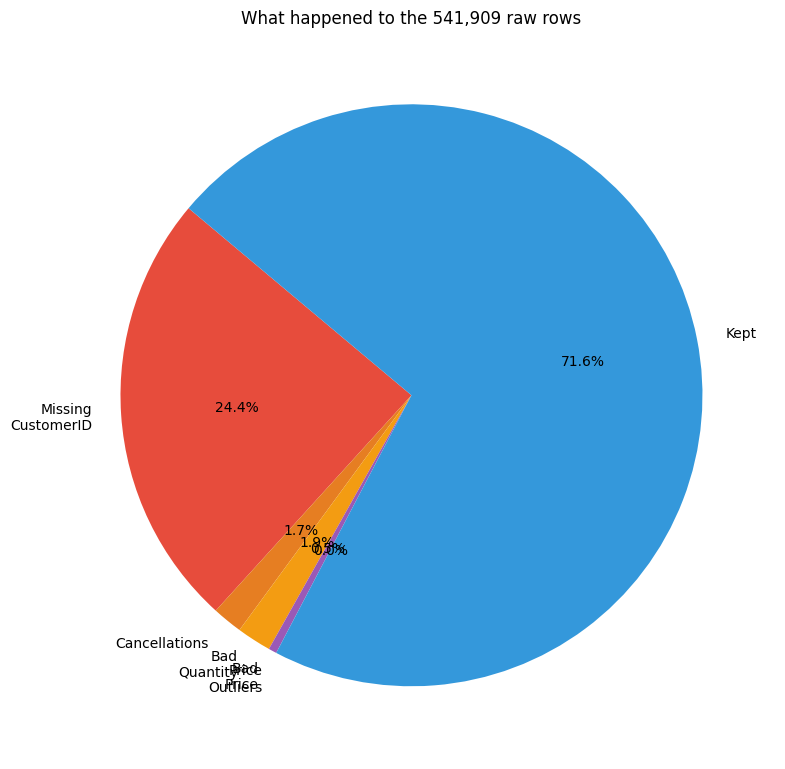

In [7]:
labels = ['Missing\nCustomerID', 'Cancellations', 'Bad\nQuantity', 'Bad\nPrice', 'Price\nOutliers', 'Kept']
raw = len(df_raw)
after_missing = raw - df_raw.dropna(subset=['CustomerID','Description']).shape[0]
after_cancel = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')].shape[0]
after_qty = df_raw[df_raw['Quantity'] <= 0].shape[0]
after_price = df_raw[df_raw['UnitPrice'] <= 0].shape[0]
kept = len(tx)
outliers = raw - after_missing - after_cancel - after_qty - after_price - kept

sizes = [after_missing, after_cancel, after_qty, after_price, max(0, outliers), kept]
colors = ['#e74c3c','#e67e22','#f39c12','#9b59b6','#1abc9c','#3498db']
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
ax.set_title(f'What happened to the {raw:,} raw rows')
plt.tight_layout()
plt.show()

## 7. Cleaning summary
| Metric | Value |
|--------|-------|
| Raw rows | 541,909 |
| Clean rows | 396,777 |
| Rows removed | 145,132 (26.8%) |
| Unique products | 3,665 |
| Date range | Dec 2010 — Dec 2011 |
| Countries | 37 |

**Ready for modelling.** Proceed to `03_demand_forecast.ipynb`.